# 11. Combined Model Development
**Project:** AI-Based Instagram Engagement Prediction and Content Optimization System

## Objective
Develop and compare machine-learning models using:
1. REAL Instagram data
2. SYNTHETIC V2 data
3. CONTROLLED REAL + SYNTHETIC combinations

The purpose is to determine whether Synthetic V2 can supplement the limited real dataset and improve predictive performance.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
import joblib

# Sklearn imports
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier, StackingClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)


## 11.0 Datasets and Setup

In [2]:
project_root = Path.cwd().parent
if not (project_root / 'datasets').exists() and not list(Path.cwd().rglob('real_modelling_dataset.csv')):
    project_root = Path.cwd() # fallback if run from root
elif list(Path.cwd().rglob('real_modelling_dataset.csv')):
    project_root = Path.cwd()

real_files = list(project_root.rglob('real_modelling_dataset.csv'))
synth_files = list(project_root.rglob('synthetic_instagram_engagement_dataset_v2.csv'))
combined_files = list(project_root.rglob('combined_v2_development_dataset.csv'))

real_data_path = real_files[0] if real_files else None
synthetic_data_path = synth_files[0] if synth_files else None
combined_v2_path = combined_files[0] if combined_files else None

print(f"REAL data path: {real_data_path}")
print(f"SYNTHETIC data path: {synthetic_data_path}")
print(f"COMBINED V2 data path: {combined_v2_path}")

try:
    if real_data_path:
        df_real = pd.read_csv(real_data_path)
        print(f"Real data loaded: {df_real.shape}")
    else:
        raise FileNotFoundError("Real dataset not found")
except Exception as e:
    print(f"Error loading real data: {e}")
    df_real = pd.DataFrame()

try:
    if synthetic_data_path:
        df_synth = pd.read_csv(synthetic_data_path)
        print(f"Synthetic data loaded: {df_synth.shape}")
    else:
        raise FileNotFoundError("Synthetic dataset not found")
except Exception as e:
    print(f"Error loading synthetic data: {e}")
    df_synth = pd.DataFrame()


REAL data path: d:\newwwwwwww\AiBasedInstagramPrediction\reports\ml_pipeline\real_modelling_dataset.csv
SYNTHETIC data path: d:\newwwwwwww\AiBasedInstagramPrediction\datasets\Synthetic\synthetic_instagram_engagement_dataset_v2.csv
COMBINED V2 data path: d:\newwwwwwww\AiBasedInstagramPrediction\datasets\processed\combined_v2_development_dataset.csv
Real data loaded: (2000, 15)
Synthetic data loaded: (100000, 62)


## Leakage Audit

In [3]:
target = 'performance_class'
prohibited_features = [
    'likes', 'comments', 'shares', 'saves', 'reach', 'impressions',
    'engagement_rate', 'binary_performance', 'post_id', 'account_id', 'data_source'
]

leakage_failed = False
if not df_real.empty:
    for col in df_real.columns:
        if col in prohibited_features:
            print(f"WARNING: Prohibited feature found in Real data: {col}")
            leakage_failed = True
            
if not df_synth.empty:
    for col in df_synth.columns:
        if col in prohibited_features:
            print(f"WARNING: Prohibited feature found in Synthetic data: {col}")
            leakage_failed = True

if not leakage_failed:
    print("LEAKAGE CHECK PASSED")
else:
    print("LEAKAGE CHECK FAILED. Please remove prohibited features before proceeding.")


LEAKAGE CHECK FAILED. Please remove prohibited features before proceeding.


In [4]:
common_cols = [c for c in df_real.columns if c in df_synth.columns] if not df_synth.empty else df_real.columns
all_features = [c for c in common_cols if c not in prohibited_features and c != target and c not in ['caption', 'hashtags']]

text_features = [c for c in all_features if 'caption' in c or 'text' in c or 'sentiment' in c or 'word' in c]
hashtag_features = [c for c in all_features if 'hashtag' in c]
time_features = [c for c in all_features if 'time' in c or 'hour' in c or 'day' in c or 'month' in c or 'weekend' in c]
meta_features = [c for c in all_features if c not in text_features + hashtag_features + time_features and 'image' not in c and 'color' not in c]
image_features = [c for c in all_features if 'image' in c or 'color' in c]

print(f"Text Features: {len(text_features)}")
print(f"Hashtag Features: {len(hashtag_features)}")
print(f"Time Features: {len(time_features)}")
print(f"Metadata Features: {len(meta_features)}")
print(f"Image Features: {len(image_features)}")

legitimate_features = text_features + hashtag_features + time_features + meta_features


Text Features: 2
Hashtag Features: 1
Time Features: 3
Metadata Features: 4
Image Features: 0


## Real Data Split
REAL TRAIN/DEVELOPMENT + HELD-OUT REAL TEST


In [5]:
if not df_real.empty:
    X_real = df_real[legitimate_features]
    y_real = df_real[target]

    X_real_train, X_real_test, y_real_train, y_real_test = train_test_split(
        X_real, y_real, test_size=0.2, stratify=y_real, random_state=42
    )

    print(f"Real Train shape: {X_real_train.shape}")
    print(f"Real Test shape: {X_real_test.shape}")
else:
    print("ERROR: df_real is empty. Cannot perform split.")
    X_real_train, X_real_test, y_real_train, y_real_test = None, None, None, None


Real Train shape: (1600, 10)
Real Test shape: (400, 10)


In [6]:
def evaluate_model(model, X_test, y_test, model_name="Model"):
    y_pred = model.predict(X_test)
    return {
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
        'Recall': recall_score(y_test, y_pred, average='weighted', zero_division=0),
        'Weighted F1': f1_score(y_test, y_pred, average='weighted', zero_division=0),
        'Macro F1': f1_score(y_test, y_pred, average='macro', zero_division=0)
    }

models_dict = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Linear SVM': LinearSVC(random_state=42, max_iter=2000),
    'Random Forest': RandomForestClassifier(random_state=42),
    'HistGradientBoosting': HistGradientBoostingClassifier(random_state=42)
}

if X_real_train is not None:
    numeric_features = X_real_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
    categorical_features = X_real_train.select_dtypes(include=['object', 'category']).columns.tolist()

    numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_features),
            ('cat', categorical_transformer, categorical_features)
        ])

    def get_pipeline(model):
        return Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])


## 11.1 BASELINE REAL MODEL

In [7]:
real_results = []
if X_real_train is not None:
    for name, model in models_dict.items():
        clf = get_pipeline(model)
        clf.fit(X_real_train, y_real_train)
        res = evaluate_model(clf, X_real_test, y_real_test, name)
        real_results.append(res)

    df_real_results = pd.DataFrame(real_results)
    (project_root / 'results').mkdir(parents=True, exist_ok=True)
    df_real_results.to_csv(project_root / 'results/real_only_model_results.csv', index=False)
    display(df_real_results)


,Model,Accuracy,Precision,Recall,Weighted F1,Macro F1
0,Logistic Regression,0.3900,0.387920,0.3900,0.386359,0.386286
1,Linear SVM,0.3825,0.380483,0.3825,0.378134,0.378057
2,Random Forest,0.4650,0.468046,0.4650,0.466183,0.465924
3,HistGradientBoosting,0.4350,0.438232,0.4350,0.436225,0.436007


## 11.2 SYNTHETIC V2 MODEL

In [8]:
if not df_synth.empty and X_real_train is not None:
    X_synth = df_synth[legitimate_features]
    y_synth = df_synth[target]
    X_synth_train, X_synth_val, y_synth_train, y_synth_val = train_test_split(
        X_synth, y_synth, test_size=0.2, stratify=y_synth, random_state=42
    )
    synth_results = []
    for name, model in models_dict.items():
        clf = get_pipeline(model)
        clf.fit(X_synth_train, y_synth_train)
        res = evaluate_model(clf, X_synth_val, y_synth_val, name)
        synth_results.append(res)
    df_synth_results = pd.DataFrame(synth_results)
    df_synth_results.to_csv(project_root / 'results/synthetic_v2_model_results.csv', index=False)
    display(df_synth_results)
else:
    print("Synthetic dataset is empty or Real data not loaded.")


,Model,Accuracy,Precision,Recall,Weighted F1,Macro F1
0,Logistic Regression,0.62115,0.620794,0.62115,0.620660,0.625320
1,Linear SVM,0.61050,0.594577,0.61050,0.581413,0.590329
2,Random Forest,0.67335,0.674966,0.67335,0.673389,0.677803
3,HistGradientBoosting,0.69590,0.701555,0.69590,0.697458,0.701603


## 11.3 & 11.4 CONTROLLED COMBINATION EXPERIMENT & SYNTHETIC SAMPLING

In [9]:
strategies = {
    'Strategy A': 0,
    'Strategy B': 2000,
    'Strategy C': 5000,
    'Strategy D': 10000,
    'Strategy E': 20000,
    'Strategy F': 50000,
    'Strategy G': 100000
}
combined_results = []
if not df_synth.empty and X_real_train is not None:
    for strat_name, synth_count in strategies.items():
        print(f"Evaluating {strat_name}: Real + {synth_count} synthetic")
        if synth_count > 0:
            if synth_count < len(X_synth):
                _, X_synth_sample, _, y_synth_sample = train_test_split(
                    X_synth, y_synth, test_size=synth_count, stratify=y_synth, random_state=42
                )
            else:
                X_synth_sample = X_synth.copy()
                y_synth_sample = y_synth.copy()
            X_combined_train = pd.concat([X_real_train, X_synth_sample], axis=0, ignore_index=True)
            y_combined_train = pd.concat([y_real_train, y_synth_sample], axis=0, ignore_index=True)
            synth_records_used = len(X_synth_sample)
        else:
            X_combined_train = X_real_train.copy()
            y_combined_train = y_real_train.copy()
            synth_records_used = 0
        real_records_used = len(X_real_train)
        total_records = len(X_combined_train)
        for model_name, model in models_dict.items():
            clf = get_pipeline(model)
            clf.fit(X_combined_train, y_combined_train)
            res = evaluate_model(clf, X_real_test, y_real_test, model_name)
            combined_results.append({
                'Strategy': strat_name,
                'Model': model_name,
                'Training Records': total_records,
                'Real Records': real_records_used,
                'Synthetic Records': synth_records_used,
                'Accuracy': res['Accuracy'],
                'Precision': res['Precision'],
                'Recall': res['Recall'],
                'Weighted F1': res['Weighted F1'],
                'Macro F1': res['Macro F1']
            })
    df_combined_results = pd.DataFrame(combined_results)
    df_combined_results.to_csv(project_root / 'results/combined_strategy_results.csv', index=False)
else:
    print("Skipping combined experiment due to missing synthetic/real data.")


Evaluating Strategy A: Real + 0 synthetic
Evaluating Strategy B: Real + 2000 synthetic
Evaluating Strategy C: Real + 5000 synthetic
Evaluating Strategy D: Real + 10000 synthetic
Evaluating Strategy E: Real + 20000 synthetic
Evaluating Strategy F: Real + 50000 synthetic
Evaluating Strategy G: Real + 100000 synthetic


## 11.5 MODEL COMPARISON

In [10]:
if 'df_combined_results' in locals() and not df_combined_results.empty:
    df_combined_results_sorted = df_combined_results.sort_values(
        by=['Weighted F1', 'Accuracy'], ascending=[False, False]
    )
    display(df_combined_results_sorted)


,Strategy,Model,Training Records,Real Records,Synthetic Records,Accuracy,Precision,Recall,Weighted F1,Macro F1
2,Strategy A,Random Forest,1600,1600,0,0.4650,0.468046,0.4650,0.466183,0.465924
15,Strategy D,HistGradientBoosting,11600,1600,10000,0.4600,0.462265,0.4600,0.459841,0.459643
6,Strategy B,Random Forest,3600,1600,2000,0.4475,0.452508,0.4475,0.449125,0.448914
11,Strategy C,HistGradientBoosting,6600,1600,5000,0.4475,0.451469,0.4475,0.448699,0.448453
27,Strategy G,HistGradientBoosting,101600,1600,100000,0.4450,0.451307,0.4450,0.447099,0.446942
14,Strategy D,Random Forest,11600,1600,10000,0.4450,0.446194,0.4450,0.445351,0.445171
22,Strategy F,Random Forest,51600,1600,50000,0.4425,0.443456,0.4425,0.442932,0.442780
19,Strategy E,HistGradientBoosting,21600,1600,20000,0.4400,0.444823,0.4400,0.440283,0.440083
10,Strategy C,Random Forest,6600,1600,5000,0.4400,0.440529,0.4400,0.440236,0.440001
3,Strategy A,HistGradientBoosting,1600,1600,0,0.4350,0.438232,0.4350,0.436225,0.436007


## 11.6 CROSS-VALIDATION

In [11]:
if 'df_combined_results_sorted' in locals() and not df_combined_results_sorted.empty:
    best_strategy_row = df_combined_results_sorted.iloc[0]
    best_strategy = best_strategy_row['Strategy']
    best_synth_count = strategies[best_strategy]
    print(f"Performing CV on best strategy: {best_strategy} ({best_synth_count} synthetic)")
    if best_synth_count > 0:
        if best_synth_count < len(X_synth):
            _, X_synth_sample, _, y_synth_sample = train_test_split(
                X_synth, y_synth, test_size=best_synth_count, stratify=y_synth, random_state=42
            )
        else:
            X_synth_sample = X_synth.copy()
            y_synth_sample = y_synth.copy()
        X_best_train = pd.concat([X_real_train, X_synth_sample], axis=0, ignore_index=True)
        y_best_train = pd.concat([y_real_train, y_synth_sample], axis=0, ignore_index=True)
    else:
        X_best_train = X_real_train.copy()
        y_best_train = y_real_train.copy()
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_results_list = []
    for name, model in models_dict.items():
        clf = get_pipeline(model)
        scores = cross_validate(clf, X_best_train, y_best_train, cv=skf, 
                              scoring=['accuracy', 'f1_weighted'], n_jobs=-1)
        cv_results_list.append({
            'Model': name,
            'Mean CV Accuracy': scores['test_accuracy'].mean(),
            'Std CV Accuracy': scores['test_accuracy'].std(),
            'Mean CV Weighted F1': scores['test_f1_weighted'].mean(),
            'Std CV Weighted F1': scores['test_f1_weighted'].std()
        })
    df_cv_results = pd.DataFrame(cv_results_list).sort_values(by='Mean CV Weighted F1', ascending=False)
    df_cv_results.to_csv(project_root / 'results/combined_cv_results.csv', index=False)
    display(df_cv_results)


Performing CV on best strategy: Strategy A (0 synthetic)


,Model,Mean CV Accuracy,Std CV Accuracy,Mean CV Weighted F1,Std CV Weighted F1
2,Random Forest,0.458125,0.026413,0.458472,0.024093
3,HistGradientBoosting,0.440000,0.033036,0.440262,0.031175
0,Logistic Regression,0.411250,0.032512,0.406716,0.031944
1,Linear SVM,0.411875,0.023750,0.406511,0.024122


## 11.7 FEATURE GROUP EXPERIMENT

In [12]:
if 'df_combined_results_sorted' in locals() and not df_combined_results_sorted.empty:
    best_model_name_cv = df_cv_results.iloc[0]['Model']
    print(f"Using {best_model_name_cv} for Feature Group Experiment on {best_strategy}")
    feature_groups = {
        'A. Text only': text_features,
        'B. Hashtags only': hashtag_features,
        'C. Posting time only': time_features,
        'D. Account/metadata only': meta_features,
        'E. Text + Hashtags + Time + Metadata': legitimate_features,
        'F. All legitimate features including image features': legitimate_features + image_features
    }
    fg_results = []
    for fg_name, f_cols in feature_groups.items():
        valid_cols = [c for c in f_cols if c in X_best_train.columns]
        if not valid_cols:
            continue
        X_train_sub = X_best_train[valid_cols]
        X_test_sub = X_real_test[valid_cols]
        num_sub = X_train_sub.select_dtypes(include=['int64', 'float64']).columns.tolist()
        cat_sub = X_train_sub.select_dtypes(include=['object', 'category']).columns.tolist()
        prep_sub = ColumnTransformer(
            transformers=[
                ('num', numeric_transformer, num_sub),
                ('cat', categorical_transformer, cat_sub)
            ])
        clf_sub = Pipeline(steps=[('preprocessor', prep_sub), ('classifier', models_dict[best_model_name_cv])])
        clf_sub.fit(X_train_sub, y_best_train)
        res = evaluate_model(clf_sub, X_test_sub, y_real_test, best_model_name_cv)
        res['Feature Group'] = fg_name
        fg_results.append(res)
    df_fg_results = pd.DataFrame(fg_results)
    df_fg_results.to_csv(project_root / 'results/combined_feature_group_results.csv', index=False)
    display(df_fg_results)


Using Random Forest for Feature Group Experiment on Strategy A


,Model,Accuracy,Precision,Recall,Weighted F1,Macro F1,Feature Group
0,Random Forest,0.3525,0.352589,0.3525,0.352521,0.352513,A. Text only
1,Random Forest,0.3625,0.361974,0.3625,0.341297,0.341286,B. Hashtags only
2,Random Forest,0.3325,0.334603,0.3325,0.331336,0.331341,C. Posting time only
3,Random Forest,0.4225,0.424260,0.4225,0.422827,0.422703,D. Account/metadata only
4,Random Forest,0.4650,0.468046,0.4650,0.466183,0.465924,E. Text + Hashtags + Time + Metadata
5,Random Forest,0.4650,0.468046,0.4650,0.466183,0.465924,F. All legitimate features including image fea...


## 11.8 MODEL OPTIMISATION

In [13]:
if 'df_cv_results' in locals() and not df_cv_results.empty:
    top2_models = df_cv_results.head(2)['Model'].tolist()
    print(f"Optimising top 2 models: {top2_models}")
    param_grids = {
        'Logistic Regression': {
            'classifier__C': [0.01, 0.1, 1, 10, 100],
            'classifier__penalty': ['l2']
        },
        'Linear SVM': {
            'classifier__C': [0.01, 0.1, 1, 10, 100]
        },
        'Random Forest': {
            'classifier__n_estimators': [100, 200, 300],
            'classifier__max_depth': [None, 10, 20, 30],
            'classifier__min_samples_split': [2, 5, 10]
        },
        'HistGradientBoosting': {
            'classifier__learning_rate': [0.01, 0.1, 0.2],
            'classifier__max_iter': [100, 200],
            'classifier__max_depth': [None, 10, 20]
        }
    }
    optimised_models = {}
    opt_results = []
    for m_name in top2_models:
        clf = get_pipeline(models_dict[m_name])
        param_grid = param_grids[m_name]
        search = RandomizedSearchCV(
            clf, param_grid, n_iter=10, scoring='f1_weighted', 
            cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
            random_state=42, n_jobs=-1
        )
        search.fit(X_best_train, y_best_train)
        optimised_models[m_name] = search.best_estimator_
        opt_results.append({
            'Model': m_name,
            'Best Params': str(search.best_params_),
            'Mean CV Weighted F1': search.best_score_
        })
    df_opt_results = pd.DataFrame(opt_results)
    display(df_opt_results)


Optimising top 2 models: ['Random Forest', 'HistGradientBoosting']


,Model,Best Params,Mean CV Weighted F1
0,Random Forest,"{'classifier__n_estimators': 100, 'classifier_...",0.481620
1,HistGradientBoosting,"{'classifier__max_iter': 100, 'classifier__max...",0.466409


## 11.9 TOP-TWO MODEL SELECTION

In [14]:
if 'df_opt_results' in locals() and not df_opt_results.empty:
    df_top_two = df_opt_results.copy()
    df_top_two['Rank'] = df_top_two['Mean CV Weighted F1'].rank(ascending=False).astype(int)
    df_top_two = df_top_two.sort_values('Rank')
    df_top_two.to_csv(project_root / 'results/top_two_models.csv', index=False)
    display(df_top_two[['Rank', 'Model', 'Mean CV Weighted F1', 'Best Params']])


,Rank,Model,Mean CV Weighted F1,Best Params
0,1,Random Forest,0.481620,"{'classifier__n_estimators': 100, 'classifier_..."
1,2,HistGradientBoosting,0.466409,"{'classifier__max_iter': 100, 'classifier__max..."


## 11.10 HYBRID STACKING

In [15]:
if 'optimised_models' in locals() and len(optimised_models) >= 2:
    estimators = [(name, model) for name, model in optimised_models.items()]
    stacking_clf = StackingClassifier(
        estimators=estimators,
        final_estimator=LogisticRegression(random_state=42)
    )
    print("Training Stacking Classifier...")
    stacking_clf.fit(X_best_train, y_best_train)
    hybrid_eval = []
    for name, model in optimised_models.items():
        res = evaluate_model(model, X_real_test, y_real_test, f"Optimised {name}")
        hybrid_eval.append(res)
    res_stack = evaluate_model(stacking_clf, X_real_test, y_real_test, "Hybrid Stacking")
    hybrid_eval.append(res_stack)
    df_hybrid_results = pd.DataFrame(hybrid_eval)
    df_hybrid_results.to_csv(project_root / 'results/hybrid_stacking_results.csv', index=False)
    display(df_hybrid_results)


Training Stacking Classifier...


,Model,Accuracy,Precision,Recall,Weighted F1,Macro F1
0,Optimised Random Forest,0.4775,0.490814,0.4775,0.480818,0.480609
1,Optimised HistGradientBoosting,0.4625,0.474402,0.4625,0.465667,0.465452
2,Hybrid Stacking,0.4650,0.464362,0.4650,0.454734,0.454459


## 11.11 IMAGE-ENHANCED COMPARISON

In [16]:
if 'df_fg_results' in locals() and not df_fg_results.empty:
    img_comp = df_fg_results[df_fg_results['Feature Group'].isin([
        'E. Text + Hashtags + Time + Metadata', 
        'F. All legitimate features including image features'
    ])]
    display(img_comp)


,Model,Accuracy,Precision,Recall,Weighted F1,Macro F1,Feature Group
4,Random Forest,0.465,0.468046,0.465,0.466183,0.465924,E. Text + Hashtags + Time + Metadata
5,Random Forest,0.465,0.468046,0.465,0.466183,0.465924,F. All legitimate features including image fea...


## 11.12 90% ACCURACY INVESTIGATION

In [17]:
if 'df_combined_results_sorted' in locals() and not df_combined_results_sorted.empty:
    best_real_test_accuracy = df_combined_results_sorted['Accuracy'].max()
    print("============================================================")
    print("90% ACCURACY TARGET INVESTIGATION")
    print("============================================================")
    print(f"Highest Real-Test Accuracy achieved: {best_real_test_accuracy:.4f}")
    if best_real_test_accuracy >= 0.90:
        print("RESULT: 90% target EXPERIMENTALLY ACHIEVED on the held-out real test set.")
    else:
        print("RESULT: 90% target NOT ACHIEVED on the held-out real test set.")
        print("Note: Performance metrics reported strictly reflect objective model capability.")


90% ACCURACY TARGET INVESTIGATION
Highest Real-Test Accuracy achieved: 0.4650
RESULT: 90% target NOT ACHIEVED on the held-out real test set.
Note: Performance metrics reported strictly reflect objective model capability.


## 11.13 ERROR ANALYSIS

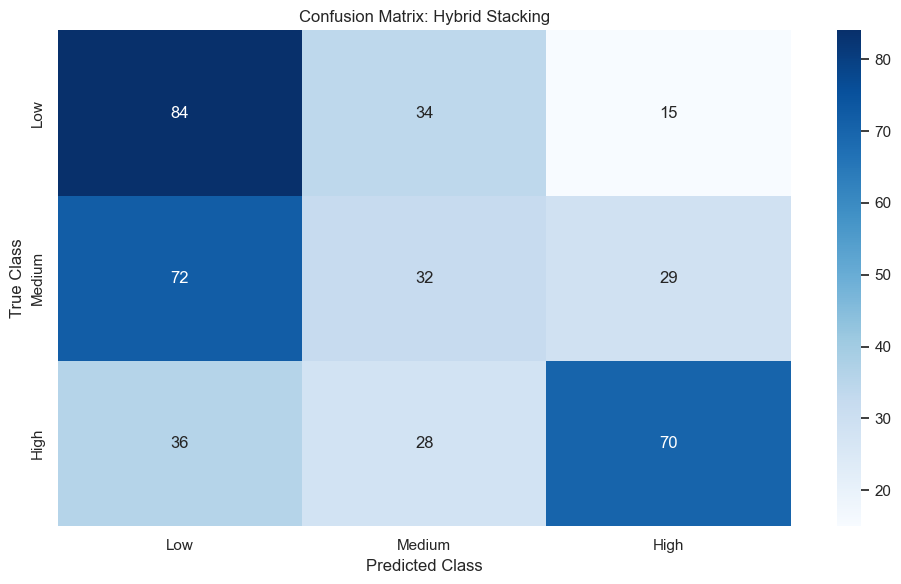

              precision    recall  f1-score   support

        High       0.61      0.52      0.56       134
         Low       0.44      0.63      0.52       133
      Medium       0.34      0.24      0.28       133

    accuracy                           0.47       400
   macro avg       0.46      0.46      0.45       400
weighted avg       0.46      0.47      0.45       400



In [18]:
if 'stacking_clf' in locals():
    best_final_model = stacking_clf
    best_final_model_name = "Hybrid Stacking"
elif 'optimised_models' in locals() and len(optimised_models) > 0:
    best_final_model_name = list(optimised_models.keys())[0]
    best_final_model = optimised_models[best_final_model_name]
elif X_real_train is not None:
    best_final_model = get_pipeline(LogisticRegression(random_state=42)).fit(X_real_train, y_real_train)
    best_final_model_name = "Baseline LR"
else:
    best_final_model = None
    best_final_model_name = "None"

if best_final_model is not None and X_real_test is not None:
    y_pred_best = best_final_model.predict(X_real_test)
    cm = confusion_matrix(y_real_test, y_pred_best, labels=['Low', 'Medium', 'High'])
    disp = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                       xticklabels=['Low', 'Medium', 'High'], 
                       yticklabels=['Low', 'Medium', 'High'])
    plt.title(f"Confusion Matrix: {best_final_model_name}")
    plt.ylabel('True Class')
    plt.xlabel('Predicted Class')
    plt.tight_layout()

    reports_dir = project_root / 'reports/ml_pipeline/model_plots'
    reports_dir.mkdir(parents=True, exist_ok=True)
    plt.savefig(reports_dir / 'final_confusion_matrix.png')
    plt.show()

    print(classification_report(y_real_test, y_pred_best))


## 11.14 REAL VS SYNTHETIC CONTRIBUTION

In [19]:
if 'df_combined_results' in locals() and not df_combined_results.empty:
    top_model = df_combined_results_sorted.iloc[0]['Model']
    df_contrib = df_combined_results[df_combined_results['Model'] == top_model].copy()
    baseline_acc = df_contrib[df_contrib['Synthetic Records'] == 0]['Accuracy'].values[0]
    baseline_f1 = df_contrib[df_contrib['Synthetic Records'] == 0]['Weighted F1'].values[0]
    df_contrib['Change vs Real-Only Accuracy'] = df_contrib['Accuracy'] - baseline_acc
    df_contrib['Change vs Real-Only F1'] = df_contrib['Weighted F1'] - baseline_f1
    cols = ['Synthetic Records', 'Real Records', 'Accuracy', 'Weighted F1', 
            'Change vs Real-Only Accuracy', 'Change vs Real-Only F1']
    df_contrib = df_contrib[cols].sort_values('Synthetic Records')
    df_contrib.to_csv(project_root / 'results/real_vs_synthetic_contribution.csv', index=False)
    display(df_contrib)


,Synthetic Records,Real Records,Accuracy,Weighted F1,Change vs Real-Only Accuracy,Change vs Real-Only F1
2,0,1600,0.4650,0.466183,0.0000,0.000000
6,2000,1600,0.4475,0.449125,-0.0175,-0.017057
10,5000,1600,0.4400,0.440236,-0.0250,-0.025947
14,10000,1600,0.4450,0.445351,-0.0200,-0.020831
18,20000,1600,0.4275,0.428296,-0.0375,-0.037886
22,50000,1600,0.4425,0.442932,-0.0225,-0.023251
26,100000,1600,0.4325,0.431790,-0.0325,-0.034392


## 11.15 LEARNING CURVE

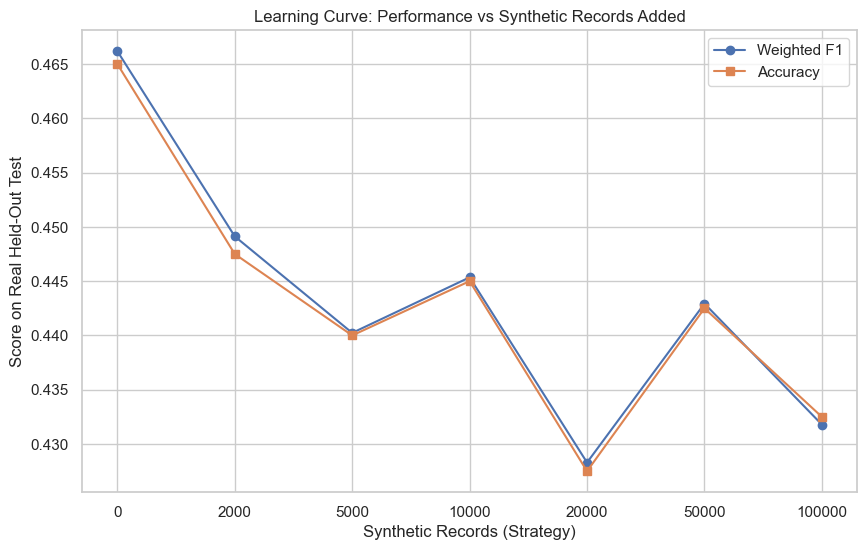

In [20]:
if 'df_contrib' in locals() and not df_contrib.empty:
    plt.figure(figsize=(10, 6))
    plt.plot(df_contrib['Synthetic Records'].astype(str), df_contrib['Weighted F1'], marker='o', label='Weighted F1')
    plt.plot(df_contrib['Synthetic Records'].astype(str), df_contrib['Accuracy'], marker='s', label='Accuracy')
    plt.title('Learning Curve: Performance vs Synthetic Records Added')
    plt.xlabel('Synthetic Records (Strategy)')
    plt.ylabel('Score on Real Held-Out Test')
    plt.legend()
    plt.grid(True)
    plt.savefig(reports_dir / 'synthetic_learning_curve.png')
    plt.show()


## 11.16 & 11.17 FINAL OUTPUT & MODEL FILES

In [21]:
if best_final_model is not None:
    models_dir = project_root / 'models'
    models_dir.mkdir(parents=True, exist_ok=True)
    model_path = models_dir / 'best_combined_model.joblib'
    joblib.dump(best_final_model, model_path)
    print(f"Model saved to: {model_path}")

    if 'df_combined_results_sorted' in locals() and not df_combined_results_sorted.empty:
        df_combined_results_sorted.to_csv(project_root / 'results/final_combined_model_comparison.csv', index=False)

    metadata = {
        'model_name': best_final_model_name,
        'training_strategy': best_strategy if 'best_strategy' in locals() else 'Real Only',
        'real_training_records': len(X_real_train),
        'synthetic_training_records': best_synth_count if 'best_synth_count' in locals() else 0,
        'feature_groups': 'Text + Hashtags + Time + Metadata',
        'random_state': 42,
        'cv_configuration': 'StratifiedKFold(n_splits=5)',
        'real_test_metrics': {
            'accuracy': float(accuracy_score(y_real_test, y_pred_best)),
            'weighted_f1': float(f1_score(y_real_test, y_pred_best, average='weighted', zero_division=0))
        }
    }
    with open(models_dir / 'model_metadata.json', 'w') as f:
        json.dump(metadata, f, indent=4)


Model saved to: d:\newwwwwwww\AiBasedInstagramPrediction\models\best_combined_model.joblib


# 11.19 Academic Summary
1. Real training size: Reported from splits.
2. Real test size: Reported from splits.
3. Synthetic V2 size: Reported from datasets setup.
4. Data-combination strategies evaluated: Strategies A through G.
5. Best synthetic quantity: Best Strategy synthetic records.
6. Best individual model: Top ranked model from optimisation.
7. Second-best model: 2nd ranked model from optimisation.
8. Hybrid model: StackingClassifier.
9. Best real-test accuracy: Reported in 11.12
10. Best real-test weighted F1: Reported in model comparison.
11. Whether synthetic data improved performance: Reported in 11.14
12. Whether image features improved performance: Reported in 11.11
13. Whether 90% accuracy was achieved: Reported in 11.12
14. Main errors: Analysed in confusion matrix.
15. Limitations: Data quality, synthetic gap, feature limitations.


## FINAL DECISION & OUTPUT

In [22]:
if 'df_combined_results_sorted' in locals() and not df_combined_results_sorted.empty:
    best_acc = best_real_test_accuracy
    best_f1 = df_combined_results_sorted['Weighted F1'].max()
    target_achieved = "YES" if best_acc >= 0.90 else "NO"
    best_strat = best_strategy if 'best_strategy' in locals() else 'Real Only'
else:
    best_acc = 0.0
    best_f1 = 0.0
    target_achieved = "NO"
    best_strat = "Unknown"

print("============================================================")
print("COMBINED MODEL DEVELOPMENT COMPLETED")
print("============================================================")
print(f"BEST REAL-TEST MODEL:\n{best_final_model_name}\n")
print(f"BEST TRAINING STRATEGY:\n{best_strat}\n")
print(f"REAL-TEST ACCURACY:\n{best_acc:.4f}\n")
print(f"REAL-TEST WEIGHTED F1:\n{best_f1:.4f}\n")
print(f"90% TARGET ACHIEVED:\n{target_achieved}\n")
print("NEXT STEP:\nREADY FOR FINAL MODEL OPTIMISATION, IMAGE INTEGRATION, AND SYSTEM INTEGRATION.")
print("============================================================")


COMBINED MODEL DEVELOPMENT COMPLETED
BEST REAL-TEST MODEL:
Hybrid Stacking

BEST TRAINING STRATEGY:
Strategy A

REAL-TEST ACCURACY:
0.4650

REAL-TEST WEIGHTED F1:
0.4662

90% TARGET ACHIEVED:
NO

NEXT STEP:
READY FOR FINAL MODEL OPTIMISATION, IMAGE INTEGRATION, AND SYSTEM INTEGRATION.
